In [1]:
from dataloader import get_loader
import os
import sys
sys.path.append(os.getcwd())

import hydra
from hydra import compose, initialize
from omegaconf import DictConfig
import torch
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt

from dataset.dataloader import get_loader

initialize(version_base=None, config_path="../config")

# Load config
cfg = compose(config_name="base_cfg")


In [3]:
%cd ..
train_loader, _, _ = get_loader(cfg.dataset)

/projects/bodymaps/Rohin/TumorSynthesis/STEP2.MaskDiffusionModel
train len 1999


/home/rpinise1/.conda/envs/synth-env/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [6]:
import torch
torch.manual_seed(42)
for i, batch in enumerate(train_loader):
    if i % 100 == 0:
        print(f"batch {i} ok")

batch 0 ok
batch 100 ok
batch 200 ok


KeyboardInterrupt: 

In [13]:
train_input["num"].mean()

np.float64(95.6031518998057)

In [22]:
train_input[train_input["volume_ml"]==train_input["volume_ml"].max()]

,bdmap_id,organ,diameter_x_mm,diameter_y_mm,diameter_z_mm,volume_ml,sphericity,surface_volume_ratio,elongation,flatness,max_3d_diameter_mm,num_components
1034,BDMAP_00058629,stomach,330.902478,250.388773,120.000011,5788.709796,0.72702,0.037046,0.807648,0.46299,332.112603,1


In [4]:
train_input.shape

(2028, 14)

In [5]:
train_input = train_input[train_input["volume_ml"] > 0.0]

In [6]:
train_input

,bdmap_id,organ,diameter_x_mm,diameter_y_mm,diameter_z_mm,volume_ml,sphericity,surface_volume_ratio,elongation,flatness,max_3d_diameter_mm,num_components,tumor_mask,organ_mask
0,BDMAP_00000004,colon,40.078125,46.406250,40.0,16.742546,0.452536,0.417725,0.678540,0.610322,55.036443,1,/projects/bodymaps/Data/radiologist_annotation...,/projects/bodymaps/Data/mask_only/AbdomenAtlas...
1,BDMAP_00000027,colon,33.593750,21.875000,20.0,5.155691,0.603085,0.464170,0.684786,0.406808,38.814525,1,/projects/bodymaps/Data/radiologist_annotation...,/projects/bodymaps/Data/mask_only/AbdomenAtlas...
2,BDMAP_00000045,colon,32.640000,34.000000,15.0,6.951799,0.528651,0.479310,0.945161,0.373348,38.757565,1,/projects/bodymaps/Data/radiologist_annotation...,/projects/bodymaps/Data/mask_only/AbdomenAtlas...
3,BDMAP_00000082,colon,22.265639,27.460955,20.0,5.249189,0.646058,0.430707,0.676786,0.478874,34.741689,1,/projects/bodymaps/Data/radiologist_annotation...,/projects/bodymaps/Data/mask_only/AbdomenAtlas...
4,BDMAP_00000096,colon,23.269522,11.320308,15.0,1.608954,0.701110,0.588641,0.613287,0.412929,25.883646,1,/projects/bodymaps/Data/radiologist_annotation...,/projects/bodymaps/Data/mask_only/AbdomenAtlas...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2365,BDMAP_00377081,stomach,20.214844,22.851562,16.5,3.189023,0.697092,0.471312,0.810777,0.661809,27.193182,1,/projects/bodymaps/Data/radiologist_annotation...,/projects/bodymaps/Data/mask_only/AbdomenAtlas...
2366,BDMAP_00377089,spleen,17.773438,13.507812,13.5,1.308311,0.739610,0.597830,0.843568,0.726685,18.150591,1,/projects/bodymaps/Data/radiologist_annotation...,/projects/bodymaps/Data/mask_only/AbdomenAtlas...
2368,BDMAP_00377099,stomach,81.375000,131.386719,81.0,173.695699,0.317684,0.272830,0.440977,0.378190,151.042952,1,/projects/bodymaps/Data/radiologist_annotation...,/projects/bodymaps/Data/mask_only/AbdomenAtlas...
2369,BDMAP_00377106,uterus,69.929181,48.617431,39.0,50.963446,0.454303,0.287113,0.754807,0.571686,74.896469,1,/projects/bodymaps/Data/radiologist_annotation...,/projects/bodymaps/Data/mask_only/AbdomenAtlas...


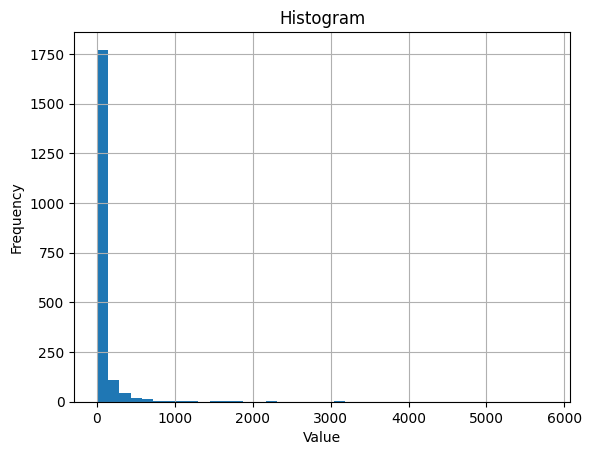

In [20]:
import matplotlib.pyplot as plt


# Plot histogram with bins
train_input["volume_ml"].hist(bins=40)

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()

In [6]:
train_input.drop(rows_to_drop,axis=0, inplace=True)

In [9]:
train_input.drop(["organ_mask","tumor_mask"],inplace=True,axis=1)

In [10]:
train_input.to_csv("RadiomicsMaskMetricsBadDropped.csv",index=False)